In [27]:
!pip install yfinance yahoofinancials

In [28]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [29]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)
sp500_table = tables[0]

tickers = sp500_table["Symbol"].tolist()

tickers = [ticker.replace(".", "-") for ticker in tickers]

print("Number of tickers:", len(tickers))
print(tickers[:10])

/tmp/ipykernel_385/1117526609.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Number of tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [30]:
import yfinance as yf

start_date = "2022-01-01"
end_date = "2025-01-01"

test_tickers = tickers[:100]

price_data = yf.download(test_tickers, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]

print("Shape:", price_data.shape)
price_data.head()

[*********************100%***********************]  100 of 100 completed

Shape: (753, 100)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,CVNA,GOOG,GOOGL,LNT,MMM,MO,SCHW,T,TECH,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702118,178.103653,115.847229,172.679993,128.345993,42.362530,383.711945,564.369995,164.526474,60.037277,...,239.630005,143.893158,143.802963,52.850285,126.958229,34.334217,80.916367,14.921769,119.623718,164.029999
2022-01-04,146.573685,175.843246,115.624802,170.800003,125.327499,42.914051,380.969849,554.000000,163.040512,61.151531,...,220.940002,143.240509,143.215836,52.737381,128.736816,35.092899,84.879166,15.044993,114.775406,156.330002
2022-01-05,144.062744,171.165817,116.232193,162.250000,124.764404,42.410072,374.260681,514.429993,160.523621,60.673992,...,198.000000,136.532578,136.645630,53.206383,128.208298,34.813747,84.265854,15.379459,106.611488,143.490005
2022-01-06,144.566879,168.308502,115.684692,159.750000,124.745956,42.657307,356.187531,514.119995,161.034393,61.213428,...,191.380005,136.430908,136.618347,52.989254,127.143990,35.221733,85.615097,15.320778,104.603004,144.660004
2022-01-07,140.718094,168.474838,115.385262,166.050003,125.133652,42.856995,349.355774,510.700012,156.808609,61.735195,...,184.710007,135.888885,135.893829,52.971893,128.536835,35.622543,86.558624,15.844190,101.841652,141.539993


In [31]:
full_price_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]

print("Full dataset shape:", full_price_data.shape)
full_price_data.head()

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


Full dataset shape: (753, 503)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103653,115.847214,172.679993,128.345963,42.362530,383.711945,564.369995,164.526443,60.037254,...,33.979385,85.125763,59.164780,54.760239,110.957497,164.029999,125.887230,120.797722,583.900024,224.021271
2022-01-04,146.573669,175.843262,115.624794,170.800003,125.327499,42.914051,380.969879,554.000000,163.040482,61.151539,...,34.414906,84.854210,59.539249,56.820000,112.134560,156.330002,126.560310,122.023201,587.599976,215.492294
2022-01-05,144.062714,171.165863,116.232170,162.250000,124.764427,42.410072,374.260742,514.429993,160.523575,60.673988,...,33.560608,81.711830,60.122723,57.526684,110.606270,143.490005,124.955948,121.620941,558.179993,207.298370
2022-01-06,144.566849,168.308502,115.684662,159.750000,124.745941,42.657307,356.187469,514.119995,161.034409,61.213432,...,33.828621,82.090057,59.652454,58.879745,110.454376,144.660004,126.246811,120.610626,555.159973,208.121597
2022-01-07,140.718079,168.474884,115.385269,166.050003,125.133614,42.856995,349.355835,510.700012,156.808609,61.735191,...,33.786743,82.002777,60.174950,59.362370,109.571594,141.539993,124.799187,119.880959,530.859985,202.062286


In [32]:
print("Before cleaning:", full_price_data.shape)

clean_data = full_price_data.dropna(axis=1)

print("After cleaning:", clean_data.shape)

Before cleaning: (753, 503)
After cleaning: (753, 495)


In [33]:
daily_returns = clean_data.pct_change().dropna()
daily_returns.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012691,-0.001920,-0.010887,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.018560,...,0.012817,-0.003190,0.006329,0.037614,0.010608,-0.046943,0.005347,0.010145,0.006337,-0.038072
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.024823,-0.037033,0.009800,0.012437,-0.013629,-0.082134,-0.012677,-0.003297,-0.050068,-0.038024
2022-01-06,0.003499,-0.016694,-0.004710,-0.015408,-0.000148,0.005830,-0.048291,-0.000603,0.003182,0.008891,...,0.007986,0.004629,-0.007822,0.023521,-0.001373,0.008154,0.010331,-0.008307,-0.005410,0.003971
2022-01-07,-0.026623,0.000989,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026242,0.008524,...,-0.001238,-0.001063,0.008759,0.008197,-0.007992,-0.021568,-0.011467,-0.006050,-0.043771,-0.029114
2022-01-10,0.000069,0.000116,0.011195,-0.032159,-0.002213,0.021078,0.006069,0.029626,0.009240,0.001719,...,-0.004709,-0.028149,0.010999,-0.005953,-0.010136,0.020772,-0.013964,-0.009754,0.008571,0.007154


In [34]:
market_data = yf.download("^GSPC", start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
market_returns = market_data.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [35]:
beta_values = {}

for ticker in daily_returns.columns:
    combined = pd.concat([daily_returns[ticker], market_returns], axis=1).dropna()
    combined.columns = ["stock", "market"]

    corr = combined["stock"].corr(combined["market"])
    beta = corr * (combined["stock"].std() / combined["market"].std())

    beta_values[ticker] = beta

beta_df = pd.DataFrame(list(beta_values.items()), columns=["Ticker", "Beta"])
beta_df.head()

,Ticker,Beta
0,A,1.024800
1,AAPL,1.210690
2,ABBV,0.299098
3,ABNB,1.666256
4,ABT,0.672317


In [36]:
import numpy as np

volatility = daily_returns.std() * np.sqrt(252)

volatility_df = pd.DataFrame({
    "Ticker": volatility.index,
    "Annual Volatility": volatility.values
})

In [37]:
avg_return = daily_returns.mean()

returns_df = pd.DataFrame({
    "Ticker": avg_return.index,
    "Average Daily Return": avg_return.values
})

In [38]:
summary_df = returns_df.merge(beta_df, on="Ticker").merge(volatility_df, on="Ticker")
summary_df.head()

,Ticker,Average Daily Return,Beta,Annual Volatility
0,A,-0.000002,1.024800,0.296259
1,AAPL,0.000591,1.210690,0.270935
2,ABBV,0.000610,0.299098,0.219958
3,ABNB,0.000074,1.666256,0.467875
4,ABT,-0.000106,0.672317,0.217839


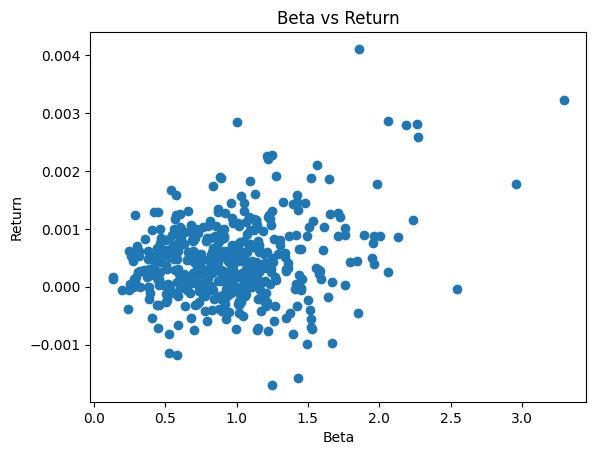

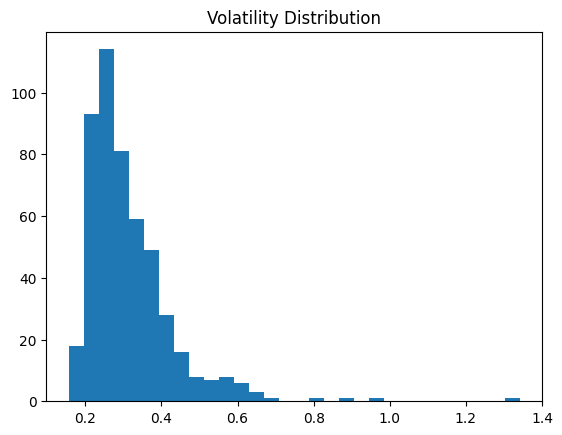

In [39]:
import matplotlib.pyplot as plt

plt.scatter(summary_df["Beta"], summary_df["Average Daily Return"])
plt.xlabel("Beta")
plt.ylabel("Return")
plt.title("Beta vs Return")
plt.show()

plt.hist(summary_df["Annual Volatility"], bins=30)
plt.title("Volatility Distribution")
plt.show()

In [40]:
daily_returns = clean_data.pct_change().dropna()
daily_returns.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012691,-0.001920,-0.010887,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.018560,...,0.012817,-0.003190,0.006329,0.037614,0.010608,-0.046943,0.005347,0.010145,0.006337,-0.038072
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.024823,-0.037033,0.009800,0.012437,-0.013629,-0.082134,-0.012677,-0.003297,-0.050068,-0.038024
2022-01-06,0.003499,-0.016694,-0.004710,-0.015408,-0.000148,0.005830,-0.048291,-0.000603,0.003182,0.008891,...,0.007986,0.004629,-0.007822,0.023521,-0.001373,0.008154,0.010331,-0.008307,-0.005410,0.003971
2022-01-07,-0.026623,0.000989,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026242,0.008524,...,-0.001238,-0.001063,0.008759,0.008197,-0.007992,-0.021568,-0.011467,-0.006050,-0.043771,-0.029114
2022-01-10,0.000069,0.000116,0.011195,-0.032159,-0.002213,0.021078,0.006069,0.029626,0.009240,0.001719,...,-0.004709,-0.028149,0.010999,-0.005953,-0.010136,0.020772,-0.013964,-0.009754,0.008571,0.007154


In [41]:
market_data = yf.download("^GSPC", start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
market_returns = market_data.pct_change().dropna()
market_returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2022-01-04,-0.000630
2022-01-05,-0.019393
2022-01-06,-0.000964
2022-01-07,-0.004050
2022-01-10,-0.001441


In [42]:
beta_values = {}

for ticker in daily_returns.columns:
    combined = pd.concat([daily_returns[ticker], market_returns], axis=1).dropna()
    combined.columns = ["stock", "market"]

    corr = combined["stock"].corr(combined["market"])
    beta = corr * (combined["stock"].std() / combined["market"].std())

    beta_values[ticker] = beta

beta_df = pd.DataFrame(list(beta_values.items()), columns=["Ticker", "Beta"])
beta_df.head()

,Ticker,Beta
0,A,1.024800
1,AAPL,1.210690
2,ABBV,0.299098
3,ABNB,1.666256
4,ABT,0.672317


In [43]:
volatility = daily_returns.std() * np.sqrt(252)

volatility_df = pd.DataFrame({
    "Ticker": volatility.index,
    "Annual Volatility": volatility.values
})

volatility_df.head()

,Ticker,Annual Volatility
0,A,0.296259
1,AAPL,0.270935
2,ABBV,0.219958
3,ABNB,0.467875
4,ABT,0.217839


In [44]:
avg_return = daily_returns.mean()

returns_df = pd.DataFrame({
    "Ticker": avg_return.index,
    "Average Daily Return": avg_return.values
})

returns_df.head()

,Ticker,Average Daily Return
0,A,-0.000002
1,AAPL,0.000591
2,ABBV,0.000610
3,ABNB,0.000074
4,ABT,-0.000106


In [45]:
summary_df = returns_df.merge(beta_df, on="Ticker").merge(volatility_df, on="Ticker")
summary_df.head()

,Ticker,Average Daily Return,Beta,Annual Volatility
0,A,-0.000002,1.024800,0.296259
1,AAPL,0.000591,1.210690,0.270935
2,ABBV,0.000610,0.299098,0.219958
3,ABNB,0.000074,1.666256,0.467875
4,ABT,-0.000106,0.672317,0.217839


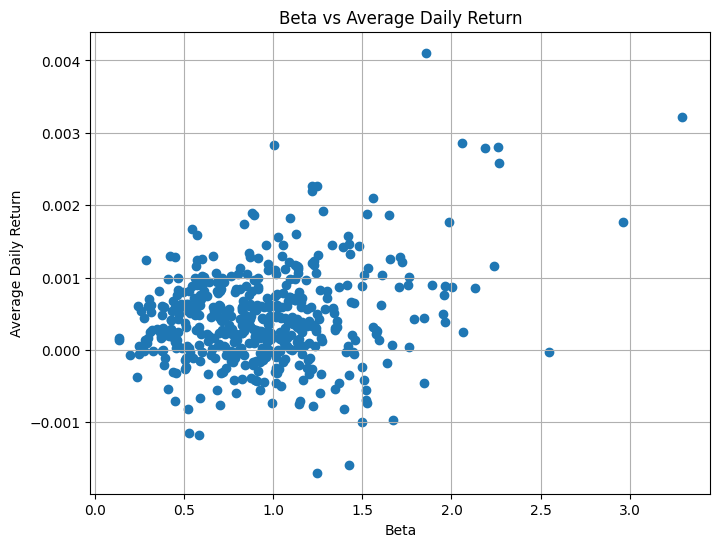

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(summary_df["Beta"], summary_df["Average Daily Return"])
plt.xlabel("Beta")
plt.ylabel("Average Daily Return")
plt.title("Beta vs Average Daily Return")
plt.grid(True)
plt.show()

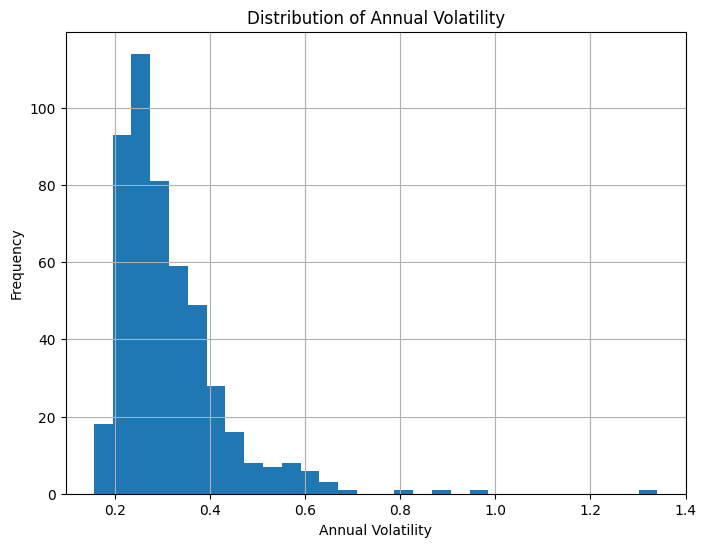

In [47]:
plt.figure(figsize=(8,6))
plt.hist(summary_df["Annual Volatility"], bins=30)
plt.xlabel("Annual Volatility")
plt.ylabel("Frequency")
plt.title("Distribution of Annual Volatility")
plt.grid(True)
plt.show()